In [1]:
from typing import TypedDict
import datetime as dt

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pyproj
import scipy
import shapely
import etas.mc_b_est as mc_b_est
import etas.utility_functions as utility_functions
import etas.simulation as simulation
from etas.inversion import polygon_surface, haversine
from matplotlib import colors
from matplotlib.path import Path as MplPath
from scipy.optimize import root_scalar
from shapely.geometry import MultiPoint, MultiPolygon, Point, Polygon
from shapely.ops import transform, voronoi_diagram
from shapely.prepared import prep
from tqdm.auto import tqdm



%matplotlib inline


2026-06-23 22:51:49.922071: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 22:51:49.956339: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-23 22:51:49.956374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-23 22:51:49.957543: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-23 22:51:49.963391: I tensorflow/core/platform/cpu_feature_guar

2026-06-23 22:51:51,991 - DEBUG - Loaded backend inline version unknown.


In [2]:
EARTH_RADIUS_KM = 6.3781e3


def _hav(theta):
    return np.square(np.sin(theta / 2))


def haversine_km(lat_rad_1, lat_rad_2, lon_rad_1, lon_rad_2, earth_radius=EARTH_RADIUS_KM):
    return (
        2
        * earth_radius
        * np.arcsin(
            np.sqrt(
                _hav(lat_rad_1 - lat_rad_2)
                + np.cos(lat_rad_1) * np.cos(lat_rad_2) * _hav(lon_rad_1 - lon_rad_2)
            )
        )
    )


def km_per_degree_at_latitude(lat_deg, earth_radius=EARTH_RADIUS_KM):
    lat_rad = np.radians(np.asarray(lat_deg, dtype=float))
    km_per_lat = haversine_km(
        lat_rad - np.radians(0.5), lat_rad + np.radians(0.5), 0.0, 0.0, earth_radius
    )
    km_per_lon = haversine_km(lat_rad, lat_rad, 0.0, np.radians(1.0), earth_radius)
    if np.ndim(km_per_lat) == 0:
        return float(km_per_lat), float(km_per_lon)
    return km_per_lat, km_per_lon


def _swap_xy(x, y):
    return y, x



In [3]:
# Grid points per side for A_h spatial quadrature (log_rhs, inverse transform, saved CSV tag).
A_H_RESOLUTION = 40

class History(TypedDict):
    m: float
    x: float
    y: float
    t: float

class EtasParams(TypedDict):
    mu: float
    k0: float
    a: float
    m_c: float
    d: float
    gamma: float
    rho: float
    c: float
    tau: float
    omega: float

def a_h(
    x: float,
    y: float,
    H: History,
    params: EtasParams,
):
    """Spatial triggering kernel at (x, y) = (lon, lat) from history event H."""
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        y, x, H["y"], H["x"]
    )
    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    return K / (dist_sq_km2 + C) ** (1 + params["rho"])


def A_h(poly: Polygon, H: History, params: EtasParams, resolution: int = 50) -> float:
    """Integrate a_h over poly; poly vertices are (lon, lat)."""
    minx, miny, maxx, maxy = poly.bounds
    if minx == maxx or miny == maxy:
        return 0.0

    x_grid = np.linspace(minx, maxx, resolution)
    y_grid = np.linspace(miny, maxy, resolution)
    X, Y = np.meshgrid(x_grid, y_grid)

    points = np.column_stack((X.ravel(), Y.ravel()))
    path = MplPath(poly.exterior.coords)
    mask = path.contains_points(points).reshape(resolution, resolution)

    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    rho1 = 1 + params["rho"]

    X_masked = X[mask]
    Y_masked = Y[mask]
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        Y_masked, X_masked, H["y"], H["x"]
    )
    kernel = K / (dist_sq_km2 + C) ** rho1

    dlon_deg = (maxx - minx) / (resolution - 1)
    dlat_deg = (maxy - miny) / (resolution - 1)
    km_per_lat, km_per_lon = utility_functions.km_per_degree_at_latitude(Y_masked)
    dA_km2 = (dlon_deg * km_per_lon) * (dlat_deg * km_per_lat)

    return float(np.sum(kernel * dA_km2))

def A_h_of_m_circ(m: float, params: EtasParams, R: float = 2) -> float:
    K = params["k0"] * np.exp(params["a"] * (m - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (m - params["m_c"]))
    return K * (np.pi/params['rho']) * 1/(C**params['rho']  - 1/((R**2 + C)**params['rho']))

def polygon_area(polygon: Polygon) -> float:
    geod = pyproj.Geod(ellps="WGS84")
    area_m2, _ = geod.geometry_area_perimeter(polygon)
    return abs(area_m2) / 1e6

def g(
    t: float,
    H : History,
    params: EtasParams,
    ):
    return np.exp(-(t - H['t']) / params['tau']) / (t - H['t'] + params['c'])**(1+params['omega'])

def etas_rate_at_xy(
    x: float,
    y: float,
    t: float,
    H : History,
    params: EtasParams,
    ):
    return params['mu']  + a_h(x, y, H, params) * g(t, H, params)

def etas_rate_space_integrated(t, S, R, H, params, resolution: int = 50):
    return params['mu']*S +A_h_of_m_circ(H['m'], params, R=R) * g(t, H, params)

def unreg_gamma_old(a, x):
    return scipy.special.gammaincc(a, x) * scipy.special.gamma(a)

def unreg_gamma(a, x):
    """
    Computes the upper incomplete gamma function Gamma(a, x).
    Uses the recurrence relation to handle negative 'a' (e.g., a = -omega).
    """
    if a > 0:
        return scipy.special.gammaincc(a, x) * scipy.special.gamma(a)
        
    elif -1 < a < 0:
        # Shift the parameter to a+1 > 0
        a_plus_1 = a + 1.0
        gamma_a_plus_1 = scipy.special.gammaincc(a_plus_1, x) * scipy.special.gamma(a_plus_1)
        return (gamma_a_plus_1 - (x**a) * np.exp(-x)) / a
    else:
        raise ValueError("Parameter 'a' is out of bounds for standard ETAS omega values.")


In [4]:
THETA_0 = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
    "m_c": 3.5,
}

for key in list(THETA_0.keys()):
    if key.startswith('log10_'):
        xx = key.replace('log10_', '')
        if xx not in THETA_0:
            THETA_0[xx] = 10 ** THETA_0[key]


THETA_0


{'log10_mu': -5.8,
 'log10_k0': -2.6,
 'a': 1.8,
 'log10_c': -2.5,
 'omega': -0.02,
 'log10_tau': 3.5,
 'log10_d': -0.85,
 'gamma': 1.3,
 'rho': 0.66,
 'm_c': 3.5,
 'mu': 1.584893192461114e-06,
 'k0': 0.0025118864315095794,
 'c': 0.0031622776601683794,
 'tau': 3162.2776601683795,
 'd': 0.14125375446227545}

In [5]:
history_event_time = "2006-12-29 00:00:00"
history_event_magnitude = 6.5
history_event_x = -120
history_event_y = 38

history_dict = {
    "m": history_event_magnitude,
    "x": history_event_x,
    "y": history_event_y,
    "t": (pd.to_datetime(history_event_time) - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D"),
}


### Define domain area

2026-06-23 22:51:52,031 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-23 22:51:52,032 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-23 22:51:52,032 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-23 22:51:52,032 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sa

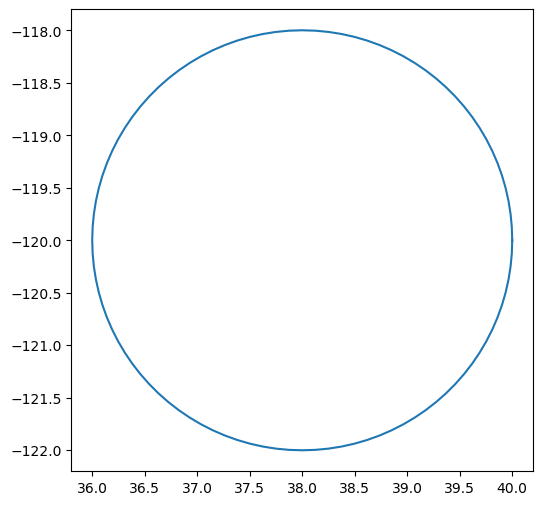

In [6]:

def regular_polygon(cx, cy, radius, n_sides):
    angles = np.linspace(0, 2 * np.pi, num=n_sides, endpoint=False)
    coords = [(cx + radius * np.cos(a), cy + radius * np.sin(a)) for a in angles]
    coords.append(coords[0])  # Ensure closure
    return Polygon(coords)

CIRCLE_RESOLUTION = 100  # Control the resolution (more sides = smoother)
CIRC_RADIUS = 2
circle = regular_polygon(history_event_y, history_event_x, CIRC_RADIUS, CIRCLE_RESOLUTION)

fig, ax = plt.subplots(figsize=(6, 6))
x_circ, y_circ = circle.exterior.xy
ax.plot(x_circ, y_circ, label="Maximum Inscribed Circle")
ax.set_aspect('equal')
plt.show()



In [7]:
# Hardcoded study-region outline (same vertices as input_data/california_shape.npy)
# Each row is [latitude, longitude].
SHAPE_COORDS = circle.exterior.xy


## verify integral

In [8]:
do_verify = False
if do_verify:
    def G(
        t: float,
        H: History,
        params: EtasParams,
    ):
        return -(np.exp(params['c'] / params['tau'])/params['tau']**(params['omega'])) * unreg_gamma(-params['omega'], (params['c'] + t - H['t'])/params['tau'])

    def G_gamma_not_regularized(
        t: float,
        H: History,
        params: EtasParams,
    ):
        return -(np.exp(params['c'] / params['tau'])/params['tau']**(-params['omega'])) * scipy.special.gammaincc(-params['omega'], (params['c'] + t - H['t'])/params['tau'])


    # numerical integral of g(t):  ∫_{t_h}^{t} g(s) ds
    # log-spaced Δt — g spikes near t_h so uniform grids are inaccurate
    dt_verify = np.concatenate([[0.0], np.geomspace(1e-6, 100.0, 500)])
    t_verify = dt_verify + history_dict['t']

    assert np.all(np.diff(dt_verify) > 0), "dt_verify must be strictly increasing"
    assert np.all(np.diff(t_verify) > 0), "t_verify must be strictly increasing"

    g_vals = g(t_verify, history_dict, THETA_0)
    G_num = scipy.integrate.cumulative_trapezoid(g_vals, t_verify, initial=0)
    G_num -= G_num[-1]

    G_analytic = G(t_verify, history_dict, THETA_0)
    G_analytic -= G_analytic[-1]

    G_gammaincc = G_gamma_not_regularized(t_verify, history_dict, THETA_0)
    G_gammaincc -= G_gammaincc[-1]

    # all y-series below share the same ascending x = dt_verify (or dt_verify[1:] on log axes)
    assert len({len(dt_verify), len(g_vals), len(G_num), len(G_analytic), len(G_gammaincc)}) == 1

    rel_err_num = np.abs(G_num - G_analytic) / np.maximum(np.abs(G_analytic), 1e-30)
    rel_err_gammaincc = np.abs(G_gammaincc - G_analytic) / np.maximum(np.abs(G_analytic), 1e-30)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(dt_verify, G_analytic, label="G analytical (unreg_gamma)")
    axes[0].plot(dt_verify, G_num, "--", label="G numerical (cumtrapz)")
    axes[0].plot(dt_verify, G_gammaincc, ":", label="G_gamma_not_regularized (gammaincc)")
    axes[0].set_xlabel(r"$\Delta t = t - t_h$ (days)")
    axes[0].set_ylabel(r"$\int_{t_h}^{t} g(s)\,ds$")
    axes[0].legend()
    axes[0].set_title("Antiderivative of g(t)")

    dt_err = dt_verify[1:]
    axes[1].semilogy(dt_err, rel_err_num[1:], label="|G_num - G_analytic| / |G_analytic|")
    axes[1].semilogy(dt_err, rel_err_gammaincc[1:], label="|G_gammaincc - G_analytic| / |G_analytic|")
    axes[1].set_xlabel(r"$\Delta t = t - t_h$ (days)")
    axes[1].set_ylabel("relative error")
    axes[1].legend()
    axes[1].set_title("Relative error vs G analytical")
    plt.tight_layout()
    plt.show()

    print(f"G(Δt=100 d) analytical:     {G_analytic[-1]:.6f}")
    print(f"G(Δt=100 d) numerical:       {G_num[-1]:.6f}")
    print(f"G(Δt=100 d) gammaincc:       {G_gammaincc[-1]:.6f}")
    print(f"max rel err G_num:            {rel_err_num[1:].max():.3e}")
    print(f"max rel err G_gammaincc:      {rel_err_gammaincc[1:].max():.3e}")

    # numerical derivative of G(t) vs g(t)
    dG_num_dt = np.gradient(G_num, dt_verify)
    dG_analytic_dt = np.gradient(G_analytic, dt_verify)
    dG_gammaincc_dt = np.gradient(G_gammaincc, dt_verify)
    deriv_rel_err_num = np.abs(dG_num_dt - g_vals) / np.maximum(np.abs(g_vals), 1e-30)
    deriv_rel_err_analytic = np.abs(dG_analytic_dt - g_vals) / np.maximum(np.abs(g_vals), 1e-30)
    deriv_rel_err_gammaincc = np.abs(dG_gammaincc_dt - g_vals) / np.maximum(np.abs(g_vals), 1e-30)

    # log-scale plots need Δt > 0; keep x and y aligned via the same slice
    dt_log = dt_verify[1:]
    g_log = g_vals[1:]
    dG_num_log = dG_num_dt[1:]
    dG_analytic_log = dG_analytic_dt[1:]
    dG_gammaincc_log = dG_gammaincc_dt[1:]
    deriv_rel_err_num_log = deriv_rel_err_num[1:]
    deriv_rel_err_analytic_log = deriv_rel_err_analytic[1:]
    deriv_rel_err_gammaincc_log = deriv_rel_err_gammaincc[1:]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(dt_log, g_log, label="g(t)")
    axes[0].plot(dt_log, dG_num_log, "--", label="dG_num/dt")
    axes[0].plot(dt_log, dG_analytic_log, ":", label="dG_analytic/dt")
    axes[0].plot(dt_log, dG_gammaincc_log, "-.", label="dG_gammaincc/dt")
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel(r"$\Delta t = t - t_h$ (days)")
    axes[0].set_ylabel("rate")
    axes[0].legend()
    axes[0].set_title("g(t) vs numerical derivative of G(t)")

    axes[1].semilogy(dt_log, deriv_rel_err_num_log, label="from G_num")
    axes[1].semilogy(dt_log, deriv_rel_err_analytic_log, label="from G_analytic")
    axes[1].semilogy(dt_log, deriv_rel_err_gammaincc_log, label="from G_gammaincc")
    axes[1].set_xscale("log")
    axes[1].set_xlabel(r"$\Delta t = t - t_h$ (days)")
    axes[1].set_ylabel("relative error")
    axes[1].set_title("|dG/dt - g| / |g|")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    print(f"max |dG_num/dt - g| / |g| (Δt > 0):       {deriv_rel_err_num_log.max():.3e}")
    print(f"max |dG_analytic/dt - g| / |g| (Δt > 0):   {deriv_rel_err_analytic_log.max():.3e}")
    print(f"max |dG_gammaincc/dt - g| / |g| (Δt > 0): {deriv_rel_err_gammaincc_log.max():.3e}")


## time to next event


In [9]:
t_prime_vec = np.linspace(0, 100, 300) + history_dict['t']

second_gamma = unreg_gamma(-THETA_0['omega'], THETA_0['c'] / THETA_0['tau'])

def log_rhs(t_prime: float, t: float, target_polygon: Polygon, H: History, params: EtasParams, resolution: int = 50):
    """
    Computes the log-space right-hand side for numerical stability.
    """
    t_h = H['t']
    
    # Linear background term
    term1 = -polygon_area(target_polygon) * params['mu'] * (t_prime - t)
    
    # Non-linear triggering term
    gamma_diff = (
        unreg_gamma(-params['omega'], (params['c'] + t_prime - t_h) / params['tau']) - 
        unreg_gamma(-params['omega'], (params['c'] + t - t_h) / params['tau'])
    )
    
    const_multiplier = np.exp(params['c'] / params['tau']) / (params['tau']**(params['omega']))
    term2 = A_h(target_polygon, H, params, resolution) * const_multiplier * gamma_diff
    
    return term1 + term2

def log_rhs_region(t_prime: float, t: float, H: History, params: EtasParams, resolution: int = 50):
    """
    Computes the log-space right-hand side for numerical stability.
    """
    t_h = H['t']
    
    # Linear background term
    term1 = -np.pi * CIRC_RADIUS**2 * params['mu'] * (t_prime - t)
    
    # Non-linear triggering term
    gamma_diff = (
        unreg_gamma(-params['omega'], (params['c'] + t_prime - t_h) / params['tau']) - 
        unreg_gamma(-params['omega'], (params['c'] + t - t_h) / params['tau'])
    )
    
    const_multiplier = np.exp(params['c'] / params['tau']) / (params['tau']**(params['omega']))
    term2 = A_h_of_m_circ(H['m'], params, R=CIRC_RADIUS) * const_multiplier * gamma_diff
    
    return term1 + term2


### prob next event entire region

2026-06-23 22:51:52,401 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
2026-06-23 22:51:52,402 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-23 22:51:52,402 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-23 22:51:52,402 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sa

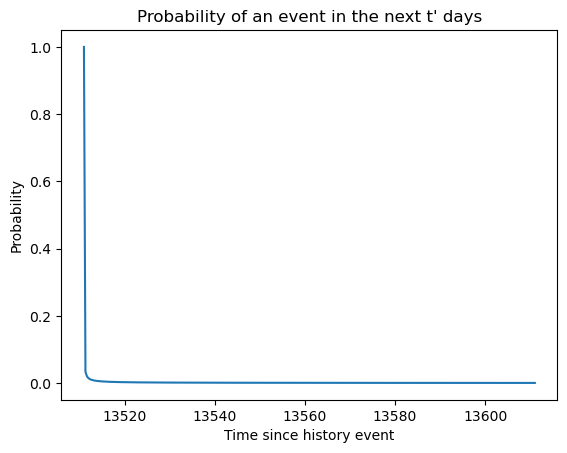

In [10]:
P_vec_california = np.exp(
    log_rhs_region(t_prime_vec, history_dict['t'], history_dict, THETA_0, resolution=A_H_RESOLUTION)
)

f, ax = plt.subplots()
ax.plot(t_prime_vec, P_vec_california)
ax.set_xlabel("Time since history event")
ax.set_ylabel("Probability")
ax.set_title("Probability of an event in the next t' days")
plt.show()


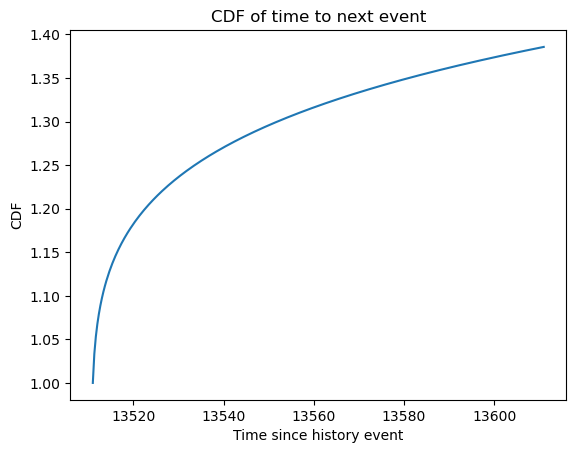

In [11]:
# cdf circ analytical
cdf_circ_analytical = np.cumsum(P_vec_california)
f, ax = plt.subplots()
ax.plot(t_prime_vec, cdf_circ_analytical)
ax.set_xlabel("Time since history event")
ax.set_ylabel("CDF")
ax.set_title("CDF of time to next event")
plt.show()


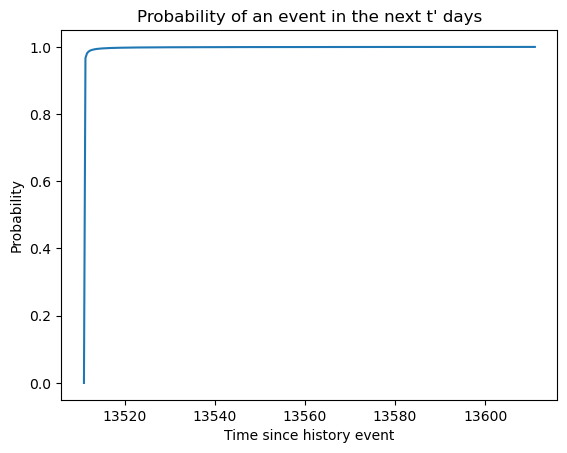

In [12]:
# Probability of NO event
S_vec_california = np.exp(
    log_rhs_region(t_prime_vec, history_dict['t'], history_dict, THETA_0, resolution=A_H_RESOLUTION)
)

# Probability of AN event (CDF)
P_vec_california = 1 - S_vec_california

f, ax = plt.subplots()
ax.plot(t_prime_vec, P_vec_california)
ax.set_xlabel("Time since history event")
ax.set_ylabel("Probability")
ax.set_title("Probability of an event in the next t' days")
plt.show()


## Catalog continuation forecast

Run classic ETAS catalog continuation (`simulate_catalog_continuation`) from forecast start time **T**, using only the single history event above as auxiliary catalog. Each recreation keeps the **first forecast event** after **T** (extending the forecast window if needed).

In [13]:
# --- forecast settings (edit these) ---
FORECAST_START = history_event_time  # time T: forecast window starts here
N_RECREATIONS = 10000
N_FORECAST_EVENTS = 1  # keep the first event after T in each recreation
SEED_START = 0

# initial forecast window; extended automatically until N_FORECAST_EVENTS are found
INITIAL_FORECAST_DAYS = 30
MAX_FORECAST_DAYS = 3650
FORECAST_GROWTH_FACTOR = 2.0

# magnitude distribution (Gutenberg–Richter b=1 => beta = ln(10))
BETA_MAIN = np.log(10)
MC = THETA_0["m_c"]

from pathlib import Path
from typing import Optional

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
RECREATIONS_OUTPUT_DIR = REPO_ROOT / "outputs" / "single_point_history_circular_domain"

# --- persistence ---
# Load only when the canonical CSV for current settings exists (n, seed, resolution, …).
# Older files with different tags are ignored; set FORCE_RECREATE_RECREATIONS = True to always re-simulate.
FORCE_RECREATE_RECREATIONS = False
SAVE_RECREATIONS_OUTPUT = True

# Optional explicit paths (str or Path); None = use canonical name under RECREATIONS_OUTPUT_DIR
SAVED_FORECAST_RECREATIONS_PATH = None
SAVED_GRID_RECREATIONS_PATH = None


def forecast_recreations_path(n_recreations=None, seed_start=None) -> Path:
    n = N_RECREATIONS if n_recreations is None else int(n_recreations)
    seed = SEED_START if seed_start is None else int(seed_start)
    return RECREATIONS_OUTPUT_DIR / f"forecast_recreations_n{n}_seed{seed}.csv"


def grid_recreations_path(n_recreations=None, resolution=None) -> Path:
    n = N_RECREATIONS if n_recreations is None else int(n_recreations)
    res = A_H_RESOLUTION if resolution is None else int(resolution)
    return RECREATIONS_OUTPUT_DIR / f"grid_recreations_n{n}_res{res}.csv"


# Backward compat for kernels that still reference the old helper name.
grid_recreations_epsilon_path = grid_recreations_path


def _resolve_saved_csv(explicit_path, canonical_path: Path) -> Optional[Path]:
    """Load only when the file matches current settings (canonical name encodes parameters)."""
    if explicit_path is not None:
        path = Path(explicit_path)
        if not path.is_file():
            raise FileNotFoundError(f"Saved recreations not found: {path}")
        if path.resolve() != canonical_path.resolve():
            print(
                f"Explicit path {path.name} does not match current settings "
                f"({canonical_path.name}); re-simulating."
            )
            return None
        return path
    if canonical_path.is_file():
        return canonical_path
    return None


def _note_stale_saved_csvs(glob_pattern: str, canonical_path: Path) -> None:
    """Hint when older CSVs exist but none match the current parameter tag."""
    if not RECREATIONS_OUTPUT_DIR.is_dir():
        return
    stale = sorted(
        RECREATIONS_OUTPUT_DIR.glob(glob_pattern),
        key=lambda p: p.name,
    )
    stale = [p for p in stale if p.resolve() != canonical_path.resolve()]
    if stale:
        names = ", ".join(p.name for p in stale[:5])
        suffix = " ..." if len(stale) > 5 else ""
        print(
            f"Note: found {len(stale)} saved CSV(s) with other parameters "
            f"({names}{suffix}); need {canonical_path.name} for current settings."
        )




In [14]:
# ETAS parameters in the log10 form expected by simulate_catalog_continuation
theta = {
    key: THETA_0[key]
    for key in [
        "log10_mu",
        "log10_k0",
        "a",
        "log10_c",
        "omega",
        "log10_tau",
        "log10_d",
        "gamma",
        "rho",
    ]
}


def _to_naive_utc(ts):
    t = pd.to_datetime(ts, utc=True)
    return t.tz_convert(None)


def simulate_single_event_recreations(
    auxiliary_catalog,
    *,
    auxiliary_start,
    forecast_start,
    polygon,
    theta,
    mc,
    beta_main,
    n_events,
    n_recreations,
    seed_start,
    initial_forecast_days=30,
    max_forecast_days=3650,
    growth_factor=2.0,
):
    """Call simulate_catalog_continuation; keep first n_events after forecast_start."""
    aux_start = _to_naive_utc(auxiliary_start)
    f_start = _to_naive_utc(forecast_start)

    aux = auxiliary_catalog.copy()
    aux["time"] = pd.to_datetime(aux["time"], utc=True).dt.tz_convert(None)

    records = []
    seeds = range(seed_start, seed_start + n_recreations)
    for i, seed in enumerate(
        tqdm(seeds, total=n_recreations, desc="Recreations", unit="run")
    ):
        np.random.seed(int(seed))

        forecast_days = float(initial_forecast_days)
        chosen = None
        while forecast_days <= float(max_forecast_days):
            sim_end = f_start + dt.timedelta(days=forecast_days)

            cont = simulation.simulate_catalog_continuation(
                auxiliary_catalog=aux,
                auxiliary_start=aux_start,
                auxiliary_end=f_start,
                polygon=polygon,
                simulation_end=sim_end,
                parameters=dict(theta),
                mc=float(mc),
                beta_main=beta_main,
                filter_polygon=False,
                magnitude_generator=mc_b_est.simulate_magnitudes,
            )

            cont = cont.copy()
            cont["time"] = pd.to_datetime(cont["time"], utc=True).dt.tz_convert(None)

            forecast_events = cont.loc[cont["time"] > f_start].sort_values("time")
            forecast_events = forecast_events.head(int(n_events))

            if len(forecast_events) >= int(n_events):
                chosen = forecast_events
                break

            forecast_days *= float(growth_factor)

        if chosen is None:
            raise RuntimeError(
                f"Recreation {i} (seed={seed}) did not reach {n_events} event(s) "
                f"within {max_forecast_days} forecast days."
            )

        chosen = chosen[["time", "latitude", "longitude", "magnitude"]].copy()
        if "is_background" in forecast_events.columns:
            chosen["event_source"] = np.where(
                forecast_events["is_background"].astype(bool).to_numpy(),
                "background",
                "history",
            )
        else:
            chosen["event_source"] = "history"
        chosen["recreation"] = i
        chosen["seed"] = int(seed)
        chosen["event_idx"] = np.arange(len(chosen), dtype=int)
        records.append(chosen)

    if not records:
        return pd.DataFrame(
            columns=[
                "time",
                "latitude",
                "longitude",
                "magnitude",
                "recreation",
                "seed",
                "event_idx",
                "event_source",
            ]
        )
    return pd.concat(records, ignore_index=True)


auxiliary_catalog = pd.DataFrame(
    {
        "time": [_to_naive_utc(history_event_time)],
        "latitude": [history_event_y],
        "longitude": [history_event_x],
        "magnitude": [history_event_magnitude],
        "xi_plus_1": [1.0],
    }
)
auxiliary_start = auxiliary_catalog["time"].min()
forecast_start = _to_naive_utc(FORECAST_START)

_forecast_canonical = forecast_recreations_path()
_forecast_load_path = None if FORCE_RECREATE_RECREATIONS else _resolve_saved_csv(
    SAVED_FORECAST_RECREATIONS_PATH,
    _forecast_canonical,
)

_forecast_loaded = False

if not FORCE_RECREATE_RECREATIONS and _forecast_load_path is not None:
    _candidate = pd.read_csv(_forecast_load_path, parse_dates=["time"])
    n_rec_ok = _candidate["recreation"].nunique() == N_RECREATIONS
    n_evt_ok = (
        _candidate.groupby("recreation")["event_idx"].max().add(1) >= N_FORECAST_EVENTS
    ).all()
    if n_rec_ok and n_evt_ok:
        print(f"Loading forecast_recreations from {_forecast_load_path}")
        forecast_recreations = _candidate
        _forecast_loaded = True
    else:
        print(
            f"Saved forecast_recreations shape does not match "
            f"n={N_RECREATIONS}, events={N_FORECAST_EVENTS}; re-simulating."
        )

if not _forecast_loaded:
    if FORCE_RECREATE_RECREATIONS:
        print("FORCE_RECREATE_RECREATIONS=True: simulating classic ETAS recreations...")
    else:
        _note_stale_saved_csvs(
            "forecast_recreations_n*_seed*.csv",
            _forecast_canonical,
        )
        if _forecast_load_path is None:
            print(
                f"No saved forecast_recreations for current settings "
                f"({_forecast_canonical.name}); simulating..."
            )
    forecast_recreations = simulate_single_event_recreations(
        auxiliary_catalog,
        auxiliary_start=auxiliary_start,
        forecast_start=forecast_start,
        polygon=circle,
        theta=theta,
        mc=MC,
        beta_main=BETA_MAIN,
        n_events=N_FORECAST_EVENTS,
        n_recreations=N_RECREATIONS,
        seed_start=SEED_START,
        initial_forecast_days=INITIAL_FORECAST_DAYS,
        max_forecast_days=MAX_FORECAST_DAYS,
        growth_factor=FORECAST_GROWTH_FACTOR,
    )

print(
    f"Forecast from T={forecast_start}: "
    f"{len(forecast_recreations)} event(s) "
    f"({forecast_recreations['recreation'].nunique()} recreations x {N_FORECAST_EVENTS})"
)

if SAVE_RECREATIONS_OUTPUT and not _forecast_loaded:
    RECREATIONS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    forecast_recreations.to_csv(_forecast_canonical, index=False)
    print(f"Saved forecast_recreations -> {_forecast_canonical}")

forecast_recreations



Loading forecast_recreations from /home/neriberman/Repos/etas/outputs/single_point_history_circular_domain/forecast_recreations_n10000_seed0.csv
Forecast from T=2006-12-29 00:00:00: 10000 event(s) (10000 recreations x 1)


,time,latitude,longitude,magnitude,recreation,seed,event_idx
0,2006-12-29 01:55:59.861478953,37.986817,-119.934974,3.745207,0,0,0
1,2006-12-29 00:01:27.132085344,37.987603,-120.032806,3.568913,1,1,0
2,2006-12-29 00:45:52.260989313,38.041409,-120.071521,5.031362,2,2,0
3,2006-12-29 00:07:54.118165641,38.006029,-119.978155,3.763826,3,3,0
4,2006-12-29 00:06:29.294487538,37.999117,-119.995402,4.085101,4,4,0
...,...,...,...,...,...,...,...
9995,2006-12-29 00:44:10.146485178,38.020008,-120.001066,3.964379,9995,9995,0
9996,2006-12-29 00:05:35.682634449,37.866557,-120.040639,4.028344,9996,9996,0
9997,2006-12-29 00:12:58.096726715,38.079037,-120.130867,3.769044,9997,9997,0
9998,2006-12-29 00:03:26.431714753,38.003522,-119.961040,3.587668,9998,9998,0


2026-06-23 22:51:53,541 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=8.0.
2026-06-23 22:51:53,541 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/cmr10.ttf', name='cmr10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-23 22:51:53,542 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-23 22:51:53,542 - DEBUG - findfont: score(FontEntry(fname='/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu San

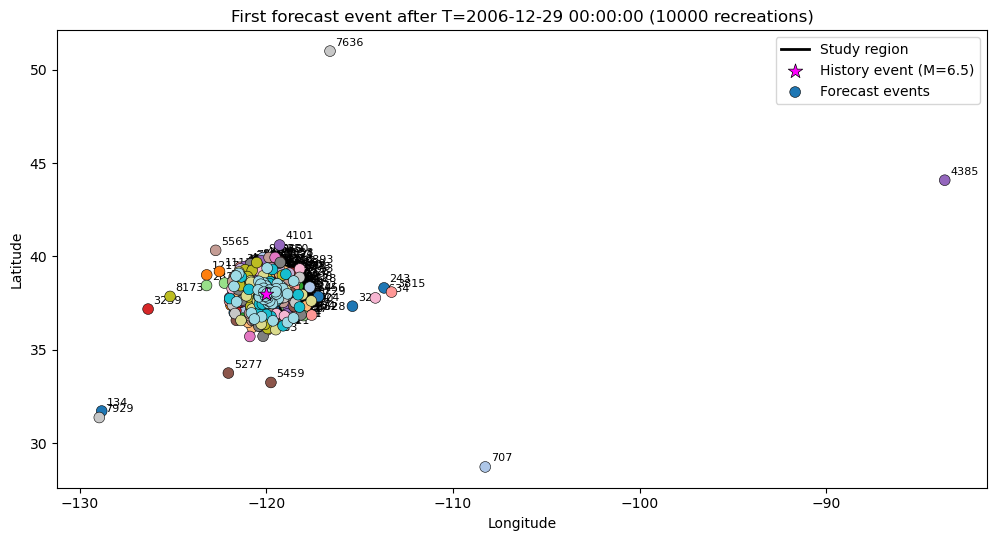

In [15]:
fig_forecast, ax = plt.subplots(figsize=(12, 10))

poly_coords = np.asarray(circle.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Study region")

ax.scatter(
    [history_event_x],
    [history_event_y],
    s=120,
    c="magenta",
    marker="*",
    edgecolors="black",
    linewidths=0.5,
    zorder=6,
    label=f"History event (M={history_event_magnitude})",
)

ax.scatter(
    forecast_recreations["longitude"],
    forecast_recreations["latitude"],
    s=60,
    c=forecast_recreations["recreation"],
    cmap="tab20",
    edgecolors="black",
    linewidths=0.4,
    zorder=5,
    label="Forecast events",
)

for _, row in forecast_recreations.iterrows():
    ax.annotate(
        str(int(row["recreation"])),
        (row["longitude"], row["latitude"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"First forecast event after T={FORECAST_START} ({N_RECREATIONS} recreations)")
ax.set_aspect("equal")
# ax.set_xlim(np.min(lon_flat) - 0.2, np.max(lon_flat) + 0.2)
# ax.set_ylim(np.min(lat_flat) - 0.2, np.max(lat_flat) + 0.2)
ax.legend(loc="upper right")
plt.show()


Recreations: 10000, first events (event_idx=0): 10000
Time to first event (days): median=0.006, 5-95%=0.000-0.254
2026-06-23 22:52:03,420 - DEBUG - vmin 0.6319940112540333 vmax 15311.853953803156
2026-06-23 22:52:03,421 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06])
2026-06-23 22:52:03,425 - DEBUG - vmin 0.6319940112540333 vmax 15311.853953803156
2026-06-23 22:52:03,425 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+0

2026-06-23 22:52:03,723 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/noto/NotoTraditionalNushu-Regular.ttf', name='Noto Traditional Nushu', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-23 22:52:03,724 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/comfortaa/Comfortaa-Regular.ttf', name='Comfortaa', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-06-23 22:52:03,724 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/opentype/fonts-hosny-amiri/Amiri-BoldSlanted.ttf', name='Amiri', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-06-23 22:52:03,724 - DEBUG - findfont: score(FontEntry(fname='/usr/share/fonts/truetype/roboto/unhinted/RobotoTTF/Roboto-BoldItalic.ttf', name='Roboto', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-06-23 22:52:03,72

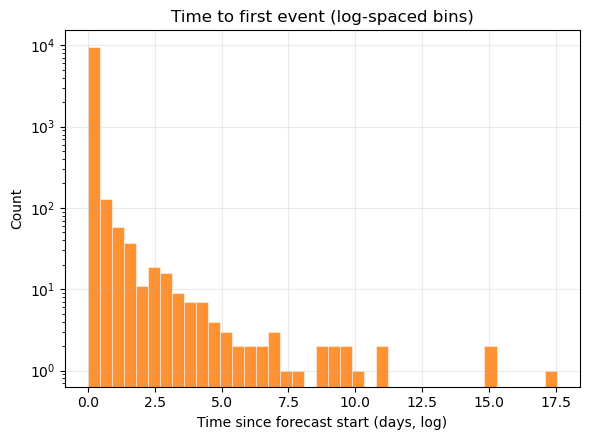

count    1.000000e+04
mean     8.968255e-02
std      5.528818e-01
min      2.232308e-07
25%      1.779412e-03
50%      5.973817e-03
75%      2.349526e-02
max      1.736163e+01
dtype: float64

In [16]:
# Time to first forecast event — same style as grid_recreations_point_process.ipynb Step 5
FIRST_EVENT_IDX = 0
SECONDS_PER_DAY = 86400.0

t0 = pd.to_datetime(FORECAST_START, utc=True)

df_rec = forecast_recreations.loc[
    forecast_recreations["event_idx"] == FIRST_EVENT_IDX
].copy()
df_rec["time"] = pd.to_datetime(df_rec["time"], utc=True)
df_rec = df_rec.sort_values(["recreation", "time"]).reset_index(drop=True)
df_rec["t_from_start_days"] = (df_rec["time"] - t0).dt.total_seconds() / SECONDS_PER_DAY

dt_to_first = df_rec.loc[df_rec["t_from_start_days"] > 0, "t_from_start_days"].to_numpy()

print(
    f"Recreations: {df_rec['recreation'].nunique()}, "
    f"first events (event_idx={FIRST_EVENT_IDX}): {len(df_rec)}"
)
if np.any(dt_to_first > 0):
    q = np.quantile(dt_to_first, [0.05, 0.5, 0.95])
    print(f"Time to first event (days): median={q[1]:.3f}, 5-95%={q[0]:.3f}-{q[2]:.3f}")

fig_delta_t, ax = plt.subplots(figsize=(6, 4.5))
bins_dt = np.linspace(
    dt_to_first.min(),
    dt_to_first.max() * 1.01,
    40,
)
# bins_dt = np.logspace(
#     np.log10(dt_to_first.min()),
#     np.log10(dt_to_first.max() * 1.01),
#     40,
# )
ax.hist(
    dt_to_first,
    bins=bins_dt,
    color="tab:orange",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)
# ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time since forecast start (days, log)")
ax.set_ylabel("Count")
ax.set_title("Time to first event (log-spaced bins)")
ax.grid(True, alpha=0.25)

fig_delta_t.tight_layout()
plt.show()

pd.Series(dt_to_first).describe()


### Analytical solution for curcular region

In [17]:
spatial_comp = lambda r, rho, gamma, m_h, m_c, d: 1/ (r**2 + d*np.exp(gamma*(m_h - m_c)))**rho

# def A_h_circ(
#     R,
#     rho,
#     gamma,
#     m_h,
#     m_c,
#     d,
#     K,
#     alpha,
#     ):
#     return K * np.pi * np.exp(alpha * (m_h - m_c)) * (spatial_comp(R, rho, gamma, m_h, m_c, d) - spatial_comp(0, rho, gamma, m_h, m_c, d))

def A_h_circ(
    R,
    m_h,
    params,
):
    return (
        (params['k0'] * np.pi * np.exp(params['a'] * (m_h - params['m_c'])) / params['rho'])
        * (
            spatial_comp(0, params['rho'], params['gamma'], m_h, params['m_c'], params['d'])
            - spatial_comp(R, params['rho'], params['gamma'], m_h, params['m_c'], params['d'])
        )
    )


S = lambda r: np.pi * r**2

def background(t_prime, params):
    return - params['mu'] * S(CIRC_RADIUS) * t_prime

def K(params):
    return np.exp(params["c"]/params["tau"]) / params['tau']**(params['omega'])


def log_t_next(t_prime, H, params):
    "When t = t_h"
    return (
        background(t_prime, params)
        + (
            A_h_circ(CIRC_RADIUS, H['m'], params) * K(params)
            * (
                unreg_gamma(-params['omega'], (params['c'] + t_prime) / params['tau'])
                - unreg_gamma(-params['omega'], params['c'] / params['tau']))
        )
    )


Text(0.5, 1.0, "Probability of no event before t'")

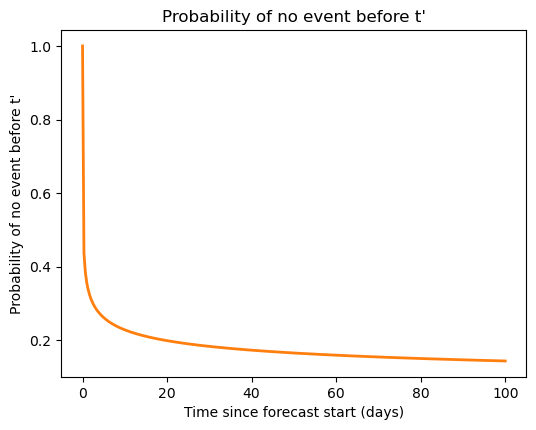

In [18]:
t_prime_vec = np.linspace(0, 100, 300)
P_no_event_before_t_prime = np.exp(log_t_next(t_prime_vec, history_dict, THETA_0))

fig_P_no_event_before_t_prime, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(t_prime_vec, P_no_event_before_t_prime, color="tab:orange", linewidth=2)
ax.set_xlabel("Time since forecast start (days)")
ax.set_ylabel("Probability of no event before t'")
ax.set_title("Probability of no event before t'")


# Ogata's modified spatio-temporal thinning method 

In [19]:
from typing import Callable


def ogata_thinning_single_step(
    temporal_intensity: Callable[[float], float],
    t0: float,
    rng: np.random.RandomState,
) -> float:
    """
    Thinning method from Ogata (1981)
    Args:
        temporal_intensity: Callable[[float], float]
            Temporal intensity function. Argument is time.
        t0: float
            current time.
        rng: np.random.RandomState
            Random number generator.
    Returns:
    float: time of the next event.
    """
    # Get upper limit for the temporal intensity
    time = t0 + 0
    current_bound = temporal_intensity(time)
    
    while True:
        tau = rng.exponential(1.0 / current_bound)
        time += tau
        next_intensity = temporal_intensity(time) 
        u = rng.uniform()
        if u < (next_intensity / current_bound):
            return time
        current_bound = next_intensity    
    


In [20]:
def magnitude_generator():
    return mc_b_est.simulate_magnitudes(1, BETA_MAIN, THETA_0['m_c'])[0]


temporal_intensity = lambda t: etas_rate_space_integrated(t, np.pi*CIRC_RADIUS**2, CIRC_RADIUS, history_dict, THETA_0, A_H_RESOLUTION)

rngseed = 1905
rng = np.random.RandomState(rngseed)
T = ogata_thinning_single_step(temporal_intensity, history_dict['t'], rng)


In [21]:
times_thinning = []
rngseed = 1905
for i in range(N_RECREATIONS):
    rng = np.random.RandomState(rngseed)
    T = ogata_thinning_single_step(temporal_intensity, history_dict['t'], rng)
    times_thinning.append(T)
    rngseed += 1



2026-06-23 22:52:11,012 - DEBUG - vmin 0.6309604994325532 vmax 15847.267790919537
2026-06-23 22:52:11,013 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06])
2026-06-23 22:52:11,016 - DEBUG - vmin 0.6309604994325532 vmax 15847.267790919537
2026-06-23 22:52:11,017 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05,
       2.e+06, 3.e+06, 4.e+06, 5.e+06, 6.e+06, 7.e+06, 8.e+06, 9.e+06])
2026-06-23 22:52:11,017

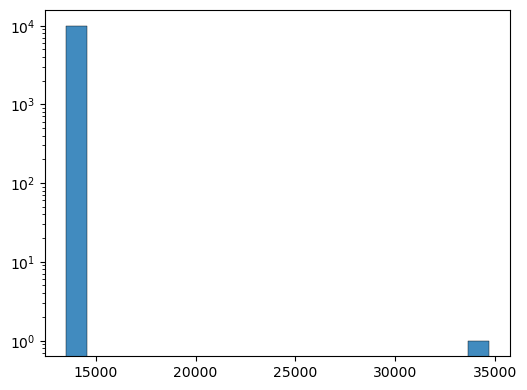

In [22]:
f, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(times_thinning, bins=20, edgecolor="black", linewidth=0.35, alpha=0.85)
ax.set_yscale("log")
plt.show()


# Apples-to-apples: three ways to forecast the first event

All three approaches target

\[
F(\Delta t) = P(\text{first event in California occurs by } T_h + \Delta t)
\]

where \(T_h\) is `history_event_time`. Plots use **CDF** \(F = 1 - S\), not survival `exp(log_rhs)`.

| Method | Implementation | Model |
|--------|----------------|-------|
| **A. Analytical** | `1 - exp(log_rhs)` | One parent event; \(\lambda=\mu + a_h(x,y)\,g(t)\); degree² `A_h`; no branching |
| **B. Grid point process** | `create_single_realization` → `min` over Voronoi cells | **Same model as A**; inverse transform per cell with random \(U_j\) |
| **C. Classic ETAS** | `simulate_catalog_continuation` | Production simulator: haversine km, discrete aftershocks, magnitude sampling |

### A vs B — should match

For B, the first event is \(T=\min_j T_j\) where each cell solves `log_rhs_j(T_j)=\log U_j`. Then

\[
P(T>\Delta t)=\prod_j \exp(\text{log\_rhs}_j)=\exp\Big(\sum_j \text{log\_rhs}_j\Big),
\qquad
F_B(\Delta t)=1-\exp\Big(\sum_j \text{log\_rhs}_j\Big).
\]

A single California integral `1 - exp(log_rhs)` is almost the same (partitioned `A_h` sums match), but the **exact** B counterpart is the product over cells. With enough Monte Carlo recreations, the B ECDF should sit on that curve (~median **0.03 days** here).

**If A and B looked far apart**, the usual cause is evaluating A on a **coarse linear** \(\Delta t\) grid (`linspace(0,100,400)` → first step \(\approx 0.25\) days) while most probability arrives before **0.05 days**. The next cell uses log-spaced \(\Delta t\) and interpolation for medians.

### C vs A/B — not just distance, not fixed by “first event only”

Keeping only the first simulated event removes later branching, but C still differs because:

- **Spatial kernel**: haversine **km** offsets (`simulate_aftershock_radius`) vs degree² integral `A_h`
- **Generative law**: Poisson **count** of aftershocks with random km locations vs continuous spatial intensity field
- **Background**: Poisson count + uniform times in window (first arrival still ~exponential, but combined with discrete aftershocks)
- **Area**: `polygon_surface` (projected km²) in simulation vs `Geod` + degree² distances in A/B

So C’s median (~**0.006 days**) can be faster than A/B (~**0.03 days**) even for the same parameters.


2026-06-23 22:52:11,159 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-23 22:52:11,160 - DEBUG - ticklocs array([1.e-10, 1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04,
       1.e+06, 1.e+08])
2026-06-23 22:52:11,164 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-23 22:52:11,165 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-23 22:52:11,165 - DEBUG - ticklocs array([1.e-10, 1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04,
       1.e+06, 1.e+08])
2026-06-23 22:52:11,166 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-23 22:52:11,166 - DEBUG - ticklocs array([1.e-10, 1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04,
       1.e+06, 1.e+08])
2026-06-23 22:52:11,167 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-23 22:52:11,167 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-23 22:52:11,167 - DEBUG - ticklocs array([1.e-10, 1.e-08, 1.e-06, 1.e-04, 1.e-02

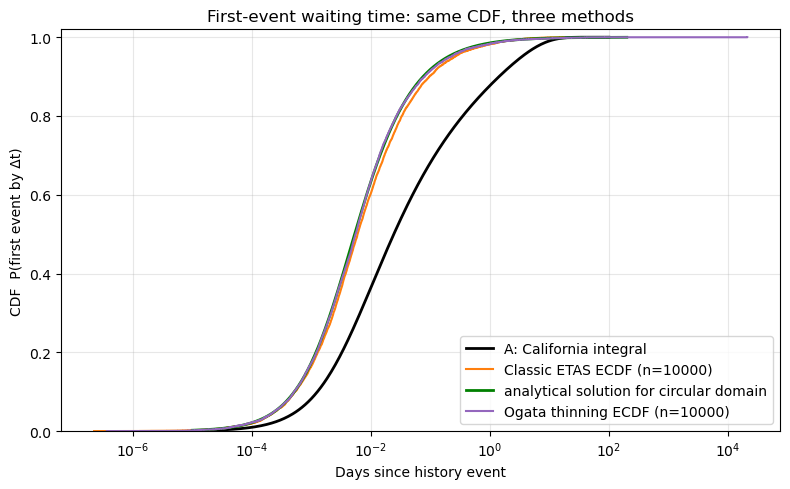

,method,n,median_days,p05_days,p95_days
0,A: California integral,400,0.024289,0.000563,3.404227
1,C: classic ETAS,10000,0.005974,0.000251,0.254138


In [23]:
def _ecdf_positive(samples):
    x = np.sort(np.asarray(samples, dtype=float))
    x = x[np.isfinite(x) & (x > 0)]
    if x.size == 0:
        return np.array([]), np.array([])
    return x, np.arange(1, x.size + 1, dtype=float) / x.size


def _analytical_median_dt(delta_t, cdf):
    cdf = np.asarray(cdf, dtype=float)
    delta_t = np.asarray(delta_t, dtype=float)
    if not np.any(cdf >= 0.5):
        return np.nan
    return float(np.interp(0.5, cdf, delta_t))


def _analytical_quantile_dt(delta_t, cdf, q):
    cdf = np.asarray(cdf, dtype=float)
    delta_t = np.asarray(delta_t, dtype=float)
    if not np.any(cdf >= q):
        return np.nan
    return float(np.interp(q, cdf, delta_t))


history_t_days = float(history_dict["t"])

california_lonlat = transform(_swap_xy, circle)
delta_t_analytical = np.geomspace(1e-5, 100.0, 400)
t_eval = delta_t_analytical + history_t_days

log_survival_ca = log_rhs(
    t_eval, history_t_days, california_lonlat, history_dict, THETA_0, A_H_RESOLUTION
)
cdf_ca = 1.0 - np.clip(np.exp(log_survival_ca), 0.0, 1.0)

# Exact B counterpart: product of per-cell survivals
log_survival_cells = np.zeros_like(delta_t_analytical, dtype=float)


# --- 3) Classic ETAS catalog continuation ---
if "dt_to_first" not in globals():
    t0 = pd.to_datetime(FORECAST_START, utc=True)
    df_rec = forecast_recreations.loc[forecast_recreations["event_idx"] == 0].copy()
    df_rec["time"] = pd.to_datetime(df_rec["time"], utc=True)
    dt_to_first = (
        df_rec.loc[df_rec["time"] > t0, "time"] - t0
    ).dt.total_seconds().to_numpy() / 86400.0
x_etas, y_etas = _ecdf_positive(dt_to_first)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    delta_t_analytical,
    cdf_ca,
    color="black",
    linewidth=2,
    label="A: California integral",
)
if x_etas.size:
    ax.step(x_etas, y_etas, where="post", color="tab:orange", linewidth=1.5, label=f"Classic ETAS ECDF (n={x_etas.size})")



# t_prime_analytical = np.linspace(0, 200, 1000)
t_prime_analytical = np.geomspace(1e-5, 200, 1000)
# P_no_event_before_t_prime = np.exp(log_t_next(t_prime_analytical, history_dict, THETA_0))
# cdf = 1 - P_no_event_before_t_prime
S_vec_circular = np.exp(
    log_rhs_region(t_prime_analytical + history_dict['t'], history_dict['t'], history_dict, THETA_0, resolution=A_H_RESOLUTION)
)
# Convert survival probability to CDF
cdf_circ_analytical = 1.0 - S_vec_circular
ax.plot(t_prime_analytical, cdf_circ_analytical, color="green", linewidth=2, label="analytical solution for circular domain")


delta_t_thinning = np.array(times_thinning) - history_t_days
x_thinning, y_thinning = _ecdf_positive(delta_t_thinning)
ax.step(x_thinning, y_thinning, where="post", color="tab:purple", linewidth=1.5, label=f"Ogata thinning ECDF (n={x_thinning.size})")



ax.set_xscale("log")
ax.set_ylim(0, 1.02)
ax.set_xlabel("Days since history event")
ax.set_ylabel("CDF  P(first event by Δt)")
ax.set_title("First-event waiting time: same CDF, three methods")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

# Summary stats for quick numeric comparison
def _quantile_row(name, x):
    if x.size == 0:
        return {"method": name, "n": 0}
    q = np.quantile(x, [0.05, 0.5, 0.95])
    return {
        "method": name,
        "n": int(x.size),
        "median_days": float(q[1]),
        "p05_days": float(q[0]),
        "p95_days": float(q[2]),
    }


summary = pd.DataFrame(
    [
        {
            "method": "A: California integral",
            "n": int(delta_t_analytical.size),
            "median_days": _analytical_median_dt(delta_t_analytical, cdf_ca),
            "p05_days": _analytical_quantile_dt(delta_t_analytical, cdf_ca, 0.05),
            "p95_days": _analytical_quantile_dt(delta_t_analytical, cdf_ca, 0.95),
        },
        _quantile_row("C: classic ETAS", dt_to_first[dt_to_first > 0]),
    ]
)
summary


# Spatial step after thinning

In [24]:
def A_h_for_weights(poly: Polygon, H: History, params: EtasParams, resolution: int = A_H_RESOLUTION) -> float:
    """Spatial triggering integral over poly in km^2.

    Self-contained, coordinate-correct version used only by the weights below
    (does not touch the upstream A_h). poly vertices are (lat, lon), so the grid
    X axis is latitude and the Y axis is longitude.
    """
    minx, miny, maxx, maxy = poly.bounds
    if minx == maxx or miny == maxy:
        return 0.0

    lat_grid = np.linspace(minx, maxx, resolution)
    lon_grid = np.linspace(miny, maxy, resolution)
    LAT, LON = np.meshgrid(lat_grid, lon_grid)

    mask = MplPath(poly.exterior.coords).contains_points(
        np.column_stack((LAT.ravel(), LON.ravel()))
    ).reshape(resolution, resolution)

    K = params["k0"] * np.exp(params["a"] * (H["m"] - params["m_c"]))
    C = params["d"] * np.exp(params["gamma"] * (H["m"] - params["m_c"]))
    lat_masked = LAT[mask]
    lon_masked = LON[mask]
    dist_sq_km2 = utility_functions.spatial_distance_squared_km2(
        lat_masked, lon_masked, H["y"], H["x"]
    )
    kernel = K / (dist_sq_km2 + C) ** (1 + params["rho"])

    dlat_deg = (maxx - minx) / (resolution - 1)
    dlon_deg = (maxy - miny) / (resolution - 1)
    km_per_lat, km_per_lon = utility_functions.km_per_degree_at_latitude(lat_masked)
    dA_km2 = (dlon_deg * km_per_lon) * (dlat_deg * km_per_lat)
    return float(np.sum(kernel * dA_km2))


def lambda_s_for_weights(poly: Polygon, H: History, params: EtasParams, t: float) -> float:
    """Space-integrated temporal intensity (km^2) consistent with the weights:
    mu * area(poly) + g(t) * A_h_for_weights(poly). Guarantees the weights sum to 1.
    """
    return params['mu'] * polygon_surface(poly) + g(t, H, params) * A_h_for_weights(poly, H, params)


def weight_of_history_point(poly: Polygon, H: History, params: EtasParams, estimation_t: float):
    return g(estimation_t, H, params) * A_h_for_weights(poly, H, params) / lambda_s_for_weights(poly, H, params, estimation_t)

def weight_of_background(poly: Polygon, params: EtasParams, estimation_t: float, H: History = history_dict):
    return params['mu'] * polygon_surface(poly) / lambda_s_for_weights(poly, H, params, estimation_t)


In [25]:
weight_of_history_point(circle, history_dict, THETA_0, T) + weight_of_background(circle, THETA_0, T)


0.9999999999999999

In [26]:
def sample_background_location(poly: Polygon):
    """Uniformly sample a (latitude, longitude) from within the polygon via rejection sampling."""
    minx, miny, maxx, maxy = poly.bounds
    while True:
        latitude = np.random.uniform(minx, maxx)
        longitude = np.random.uniform(miny, maxy)
        if poly.contains(Point(latitude, longitude)):
            return latitude, longitude

print(sample_background_location(circle))



(39.13930346198934, -121.26228205059196)


In [40]:
def sample_event_location(
    H: dict,
    params: dict,
):
    r = simulation.simulate_aftershock_radius(params['log10_d'], params['gamma'], params['rho'], [H['m']], params['m_c'])[0]
    angle = np.random.uniform(0, 2 * np.pi)
    degree_lon = haversine(
        np.radians(H['y']),
        np.radians(H['y']),
        np.radians(0),
        np.radians(1),
        EARTH_RADIUS_KM,
    )
    degree_lat = haversine(
        np.radians(H['y'] - 0.5),
        np.radians(H['y'] + 0.5),
        np.radians(0),
        np.radians(0),
        EARTH_RADIUS_KM,
    )
    latitude = (
        H['y']
        + (r * np.cos(angle))
        / degree_lat
    )
    longitude = (
        H['x']
        + (r * np.sin(angle))
        / degree_lon
    )
    return float(latitude), float(longitude)


In [41]:
sample_event_location(history_dict, THETA_0)


(38.00789285125026, -120.00819557589881)

In [42]:
def sample_location(
    H: dict,
    params: dict,
    estimation_t: float = T,
    poly: Polygon = circle,
    rng: np.random.RandomState = rng,
):
    """Sample a (latitude, longitude) for the event at ``estimation_t``.

    Returns (latitude, longitude, event_source) where event_source is
    ``"history"`` (triggered from the parent) or ``"background"``.
    """
    weights = np.array(
        [
            weight_of_history_point(poly, H, params, estimation_t),
            weight_of_background(poly, params, estimation_t),
        ],
        dtype=float,
    )
    weights /= weights.sum()
    parent_idx = rng.choice(len(weights), p=weights)
    if parent_idx == 0:
        lat_i, lon_i = sample_event_location(H, params)
        return lat_i, lon_i, "history"
    lat_i, lon_i = sample_background_location(poly)
    return lat_i, lon_i, "background"

sample_location(history_dict, THETA_0)


(38.0148856361042, -120.02475655946967, 'history')

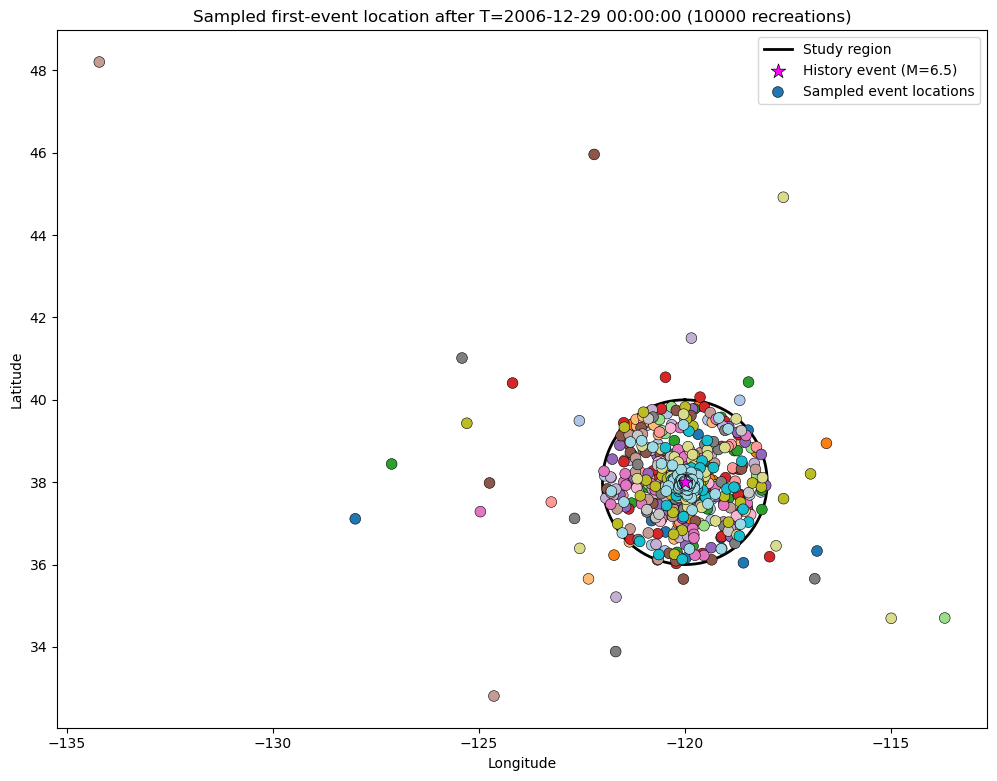

In [43]:
# Sample one location per thinning time and plot, mirroring the forecast scatter.
rng_locations = np.random.RandomState(2718)
sampled_lats = []
sampled_lons = []
sampled_sources = []
for T_i in times_thinning:
    lat_i, lon_i, source_i = sample_location(
        history_dict, THETA_0, estimation_t=T_i, poly=circle, rng=rng_locations
    )
    sampled_lats.append(lat_i)
    sampled_lons.append(lon_i)
    sampled_sources.append(source_i)

fig_thinning_loc, ax = plt.subplots(figsize=(12, 10))

poly_coords = np.asarray(circle.exterior.coords)
lat_poly, lon_poly = poly_coords[:, 0], poly_coords[:, 1]
ax.plot(lon_poly, lat_poly, color="black", linewidth=2, label="Study region")

ax.scatter(
    [history_event_x],
    [history_event_y],
    s=120,
    c="magenta",
    marker="*",
    edgecolors="black",
    linewidths=0.5,
    zorder=6,
    label=f"History event (M={history_event_magnitude})",
)

ax.scatter(
    sampled_lons,
    sampled_lats,
    s=60,
    c=np.arange(len(sampled_lons)),
    cmap="tab20",
    edgecolors="black",
    linewidths=0.4,
    zorder=5,
    label="Sampled event locations",
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"Sampled first-event location after T={FORECAST_START} "
    f"({len(times_thinning)} recreations)"
)
ax.set_aspect("equal")
ax.legend(loc="upper right")
plt.show()


2026-06-24 10:55:03,679 - DEBUG - vmin 0.7996445176626881 vmax 15671.123910697608
2026-06-24 10:55:03,680 - DEBUG - ticklocs array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06])
2026-06-24 10:55:03,684 - DEBUG - vmin 0.7996445176626881 vmax 15671.123910697608
2026-06-24 10:55:03,684 - DEBUG - ticklocs array([2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03,
       2.e+04, 3.e+04, 4.e+04, 5.e+04, 6.e+04, 7.e+04, 8.e+04, 9.e+04,
       2.e+05, 3.e+05, 4.e+05, 5.e+05, 6.e+05, 7.e+05, 8.e+05, 9.e+05,
       2.e+06, 3.e+06, 4.e+06, 5.e+06, 6.e+06, 7.e+06, 8.e+06, 9.e+06])
2026-06-24 10:55:03,685

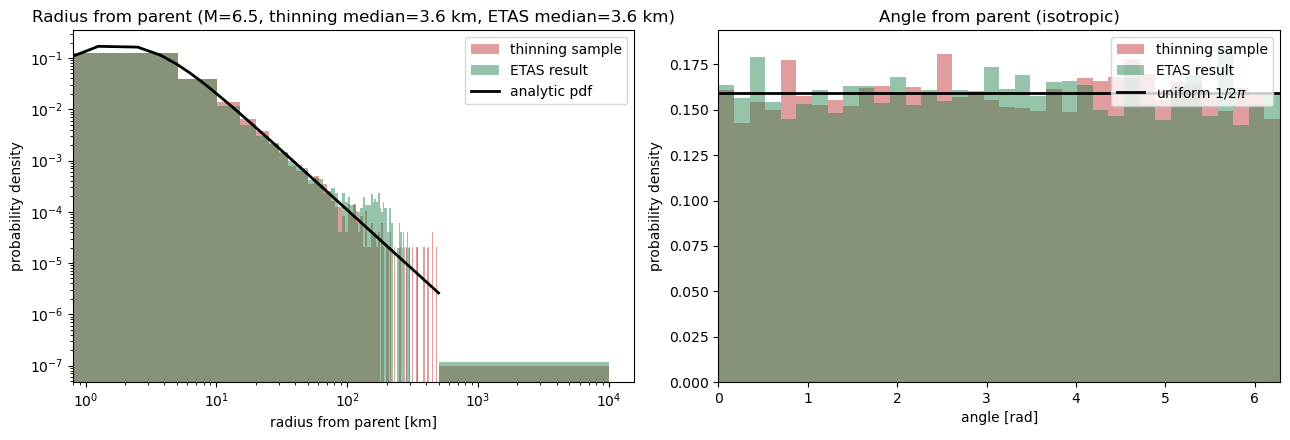

In [47]:
# Radius/angle distributions relative to the parent (history) event.
# Reuse the results computed above (no re-simulation):
#   - thinning sample: sampled_lats / sampled_lons (one location per thinning time)
#   - ETAS result:     forecast_recreations
H = history_dict
p = THETA_0
km_per_lat, km_per_lon = utility_functions.km_per_degree_at_latitude(H["y"])


def radii_angles_from(lats, lons):
    lats = np.asarray(lats, dtype=float)
    lons = np.asarray(lons, dtype=float)
    radii = np.sqrt(
        utility_functions.spatial_distance_squared_km2(lats, lons, H["y"], H["x"])
    )
    angles = np.mod(
        np.arctan2((lons - H["x"]) * km_per_lon, (lats - H["y"]) * km_per_lat),
        2 * np.pi,
    )
    return radii, angles


# Set to "history", "background", or None to include all events.
# HISTOGRAM_SOURCE = None
HISTOGRAM_SOURCE = "history"
# HISTOGRAM_SOURCE = "background"


def _source_mask(sources, label):
    sources = np.asarray(sources)
    if label is None:
        return np.ones(len(sources), dtype=bool)
    return sources == label


def _event_source_series(df):
    if "event_source" in df.columns:
        return df["event_source"].to_numpy()
    if "is_background" in df.columns:
        return np.where(df["is_background"].astype(bool).to_numpy(), "background", "history")
    return np.full(len(df), "history", dtype=object)


thin_mask = _source_mask(sampled_sources, HISTOGRAM_SOURCE)
thin_lats = np.asarray(sampled_lats)[thin_mask]
thin_lons = np.asarray(sampled_lons)[thin_mask]

etas_sources = _event_source_series(forecast_recreations)
etas_mask = _source_mask(etas_sources, HISTOGRAM_SOURCE)
etas_df = forecast_recreations.loc[etas_mask]

# Thinning sample (from the cell above).
samp_radii, samp_angles = radii_angles_from(thin_lats, thin_lons)
# ETAS simulation result (from above).
etas_radii, etas_angles = radii_angles_from(
    etas_df["latitude"], etas_df["longitude"]
)

# Analytic radial pdf: f(r) = 2*rho*r*D**rho / (r**2 + D)**(1+rho), D = d*exp(gamma*(m-mc)).
D = p['d'] * np.exp(p['gamma'] * (H['m'] - p['m_c']))
# r_max = max(samp_radii.max(), etas_radii.max())
r_max = 500
r_grid = np.linspace(0, r_max, 400)
pdf_r = 2 * p['rho'] * r_grid * D ** p['rho'] / (r_grid ** 2 + D) ** (1 + p['rho'])

THINNING_COLOR = "indianred"
ETAS_COLOR = "seagreen"

fig_dist, (ax_r, ax_a) = plt.subplots(1, 2, figsize=(13, 4.5))

bins = np.linspace(0, 500, 100)
bins = np.concatenate((bins, [10_000]))
ax_r.hist(samp_radii, bins=bins, range=(0, r_max), density=True,
          color=THINNING_COLOR, alpha=0.6, label="thinning sample")
ax_r.hist(etas_radii, bins=bins, range=(0, r_max), density=True,
          color=ETAS_COLOR, alpha=0.5, label="ETAS result")
ax_r.plot(r_grid, pdf_r, color="black", lw=2, label="analytic pdf")
ax_r.set_xlabel("radius from parent [km]")
ax_r.set_ylabel("probability density")
ax_r.set_title(
    f"Radius from parent (M={H['m']}, "
    f"thinning median={np.median(samp_radii):.1f} km, "
    f"ETAS median={np.median(etas_radii):.1f} km)"
)
ax_r.legend()
# ax_r.set_xlim(0, max(samp_radii.max(), etas_radii.max()))
ax_r.set_yscale("log")
ax_r.set_xscale("log")

ax_a.hist(samp_angles, bins=36, range=(0, 2 * np.pi), density=True,
          color=THINNING_COLOR, alpha=0.6, label="thinning sample")
ax_a.hist(etas_angles, bins=36, range=(0, 2 * np.pi), density=True,
          color=ETAS_COLOR, alpha=0.5, label="ETAS result")
ax_a.axhline(1 / (2 * np.pi), color="black", lw=2, label=r"uniform $1/2\pi$")
ax_a.set_xlabel("angle [rad]")
ax_a.set_ylabel("probability density")
ax_a.set_title("Angle from parent (isotropic)")
ax_a.set_xlim(0, 2 * np.pi)
ax_a.legend()

plt.tight_layout()
plt.show()


## Summary — circular domain, single history event

Tables and recap figures assembled from variables computed above. Re-run this cell after updating upstream cells.


### Configuration

setting,value
History time (UTC),2006-12-29 00:00:00
History magnitude,6.500000
History lon / lat,"-120.0000, 38.0000"
Forecast start T,2006-12-29 00:00:00
Circular domain radius (deg),2
Domain area (km²),122411.20
N recreations,10000
A_h grid resolution,40
Histogram source filter,history
mu,1.585e-06


### First-event waiting time Δt (days since history event)

,n,median [days],5% [days],95% [days]
metric,,,,
Analytical (circle polygon integral),400,0.0243,0.0006,3.4042
Analytical (circular domain),1000,0.0053,0.0002,0.1954
Ogata thinning,10000,0.0055,0.0002,0.2169
Classic ETAS continuation,10000,0.0060,0.0003,0.2541


### Spatial distance from parent (km)

,n,median,5%,95%
metric,,,,
Thinning radius from parent [km],9722,3.64,0.75,24.72
ETAS radius from parent [km],10000,3.64,0.78,32.00


### Event source mix (history-triggered vs background)

,history,background,total
sample,,,
Thinning locations,9722,278,10000
ETAS first events,10000,0,10000


2026-06-24 11:22:09,189 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-24 11:22:09,190 - DEBUG - ticklocs array([1.e-10, 1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04,
       1.e+06, 1.e+08])
2026-06-24 11:22:09,194 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-24 11:22:09,194 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-24 11:22:09,194 - DEBUG - ticklocs array([1.e-10, 1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04,
       1.e+06, 1.e+08])
2026-06-24 11:22:09,195 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-24 11:22:09,195 - DEBUG - ticklocs array([1.e-10, 1.e-08, 1.e-06, 1.e-04, 1.e-02, 1.e+00, 1.e+02, 1.e+04,
       1.e+06, 1.e+08])
2026-06-24 11:22:09,196 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-24 11:22:09,196 - DEBUG - vmin 6.307879120086888e-08 vmax 74996.3070579684
2026-06-24 11:22:09,196 - DEBUG - ticklocs array([1.e-10, 1.e-08, 1.e-06, 1.e-04, 1.e-02

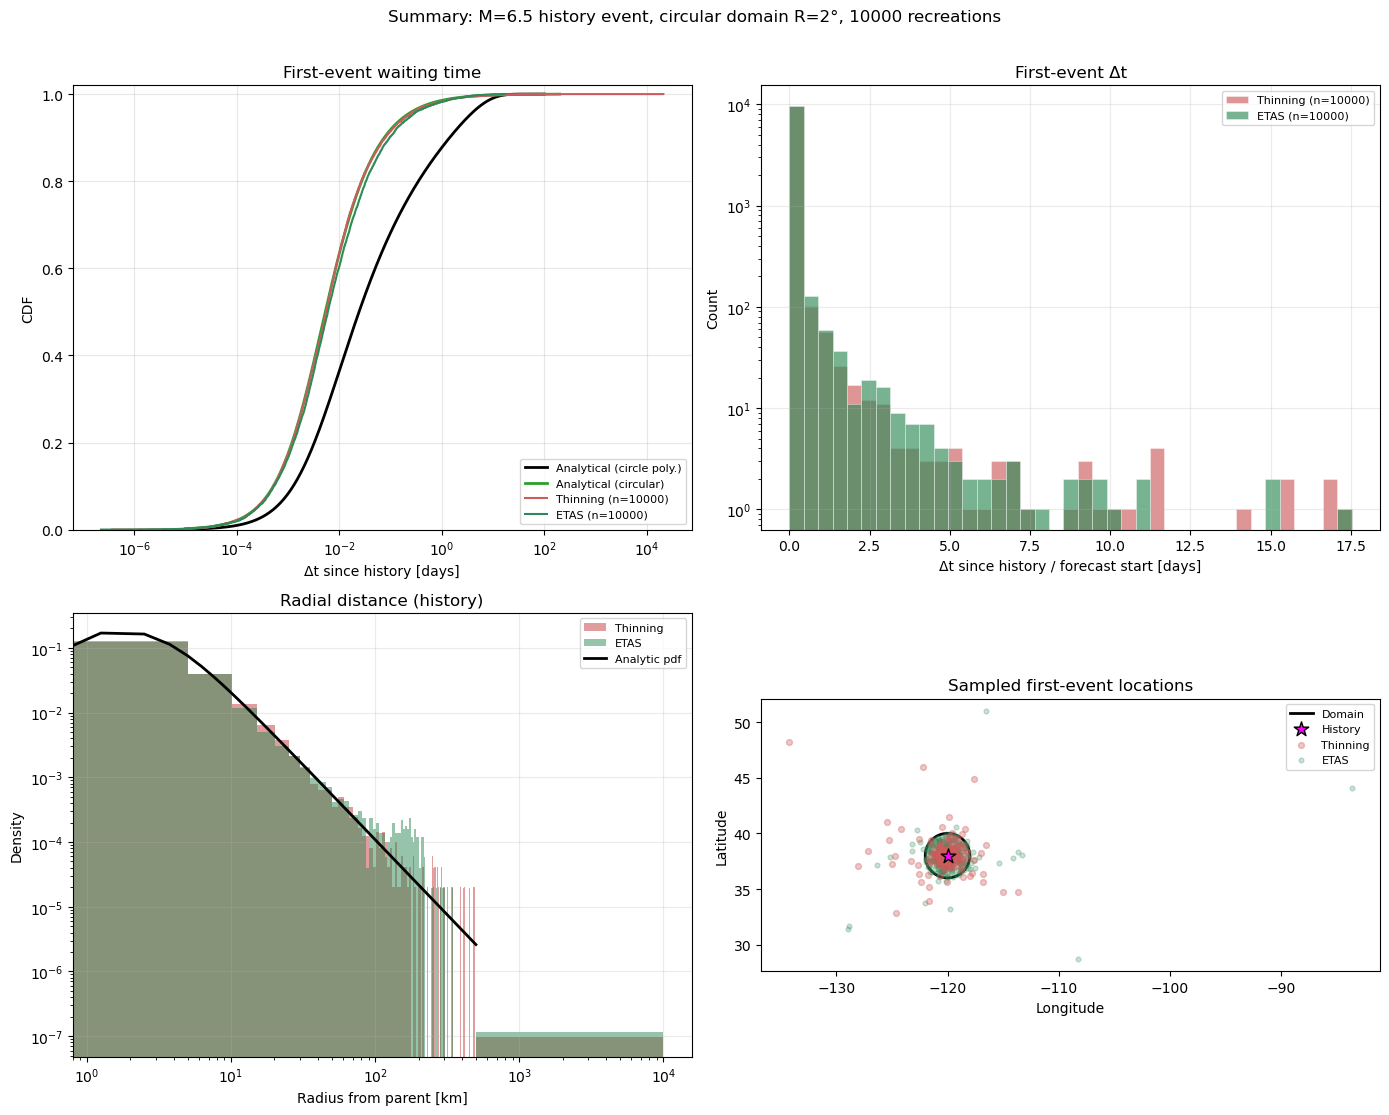

In [49]:
from IPython.display import Markdown, display

THINNING_COLOR = "indianred"
ETAS_COLOR = "seagreen"


if "_ecdf_positive" not in globals():
    def _ecdf_positive(samples):
        x = np.sort(np.asarray(samples, dtype=float))
        x = x[np.isfinite(x) & (x > 0)]
        if x.size == 0:
            return np.array([]), np.array([])
        return x, np.arange(1, x.size + 1, dtype=float) / x.size


if "_event_source_series" not in globals():
    def _event_source_series(df):
        if "event_source" in df.columns:
            return df["event_source"].to_numpy()
        if "is_background" in df.columns:
            return np.where(df["is_background"].astype(bool).to_numpy(), "background", "history")
        return np.full(len(df), "history", dtype=object)


def _quantile_stats(name, x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x) & (x > 0)]
    if x.size == 0:
        return {"metric": name, "n": 0, "median": np.nan, "p05": np.nan, "p95": np.nan}
    q = np.quantile(x, [0.05, 0.5, 0.95])
    return {
        "metric": name,
        "n": int(x.size),
        "median": float(q[1]),
        "p05": float(q[0]),
        "p95": float(q[2]),
    }


def _analytical_dt_quantiles(delta_t, cdf, label):
    delta_t = np.asarray(delta_t, dtype=float)
    cdf = np.asarray(cdf, dtype=float)
    if delta_t.size == 0:
        return {"metric": label, "n": 0, "median": np.nan, "p05": np.nan, "p95": np.nan}
    return {
        "metric": label,
        "n": int(delta_t.size),
        "median": float(np.interp(0.5, cdf, delta_t)),
        "p05": float(np.interp(0.05, cdf, delta_t)),
        "p95": float(np.interp(0.95, cdf, delta_t)),
    }


def _source_counts(sources, label):
    s = pd.Series(np.asarray(sources, dtype=object))
    vc = s.value_counts()
    return {
        "sample": label,
        "history": int(vc.get("history", 0)),
        "background": int(vc.get("background", 0)),
        "total": int(len(s)),
    }


history_t_days = float(history_dict["t"])
delta_t_thinning = np.asarray(times_thinning, dtype=float) - history_t_days
dt_etas = np.asarray(dt_to_first, dtype=float)
dt_etas = dt_etas[dt_etas > 0]
hist_source_filter = globals().get("HISTOGRAM_SOURCE", None)

cfg_rows = [
    ("History time (UTC)", history_event_time),
    ("History magnitude", history_event_magnitude),
    ("History lon / lat", f"{history_event_x:.4f}, {history_event_y:.4f}"),
    ("Forecast start T", FORECAST_START),
    ("Circular domain radius (deg)", CIRC_RADIUS),
    ("Domain area (km²)", f"{polygon_surface(circle):.2f}"),
    ("N recreations", N_RECREATIONS),
    ("A_h grid resolution", A_H_RESOLUTION),
    ("Histogram source filter", hist_source_filter if hist_source_filter is not None else "all"),
    ("mu", f"{THETA_0['mu']:.3e}"),
    ("k0", f"{THETA_0['k0']:.3e}"),
    ("a", THETA_0["a"]),
    ("c", f"{THETA_0['c']:.3e}"),
    ("tau (days)", f"{THETA_0['tau']:.3f}"),
    ("omega", THETA_0["omega"]),
    ("d", f"{THETA_0['d']:.3f}"),
    ("gamma", THETA_0["gamma"]),
    ("rho", THETA_0["rho"]),
]
config_table = pd.DataFrame(cfg_rows, columns=["setting", "value"])

waiting_rows = [
    _analytical_dt_quantiles(delta_t_analytical, cdf_ca, "Analytical (circle polygon integral)"),
    _analytical_dt_quantiles(t_prime_analytical, cdf_circ_analytical, "Analytical (circular domain)"),
    _quantile_stats("Ogata thinning", delta_t_thinning),
    _quantile_stats("Classic ETAS continuation", dt_etas),
]
waiting_table = pd.DataFrame(waiting_rows).set_index("metric")
waiting_table = waiting_table.rename(
    columns={"median": "median [days]", "p05": "5% [days]", "p95": "95% [days]"}
)

if "thin_mask" in globals():
    thin_lats_sum = np.asarray(sampled_lats)[thin_mask]
    thin_lons_sum = np.asarray(sampled_lons)[thin_mask]
else:
    thin_lats_sum = np.asarray(sampled_lats)
    thin_lons_sum = np.asarray(sampled_lons)

if "etas_df" in globals():
    etas_lats_sum = etas_df["latitude"].to_numpy()
    etas_lons_sum = etas_df["longitude"].to_numpy()
else:
    etas_lats_sum = forecast_recreations["latitude"].to_numpy()
    etas_lons_sum = forecast_recreations["longitude"].to_numpy()


def _radii_from_parent(lats, lons):
    return np.sqrt(
        utility_functions.spatial_distance_squared_km2(
            np.asarray(lats, dtype=float),
            np.asarray(lons, dtype=float),
            history_dict["y"],
            history_dict["x"],
        )
    )


thin_r = _radii_from_parent(thin_lats_sum, thin_lons_sum)
etas_r = _radii_from_parent(etas_lats_sum, etas_lons_sum)

spatial_rows = [
    _quantile_stats("Thinning radius from parent [km]", thin_r),
    _quantile_stats("ETAS radius from parent [km]", etas_r),
]
spatial_table = pd.DataFrame(spatial_rows).set_index("metric")
spatial_table = spatial_table.rename(columns={"median": "median", "p05": "5%", "p95": "95%"})

source_table = pd.DataFrame(
    [
        _source_counts(sampled_sources, "Thinning locations"),
        _source_counts(_event_source_series(forecast_recreations), "ETAS first events"),
    ]
).set_index("sample")

display(Markdown("### Configuration"))
display(config_table.style.hide(axis="index"))

display(Markdown("### First-event waiting time Δt (days since history event)"))
display(waiting_table.style.format(precision=4))

display(Markdown("### Spatial distance from parent (km)"))
display(spatial_table.style.format(precision=2))

display(Markdown("### Event source mix (history-triggered vs background)"))
display(source_table)

D = THETA_0["d"] * np.exp(THETA_0["gamma"] * (history_dict["m"] - THETA_0["m_c"]))
r_max_plot = r_max if "r_max" in globals() else 500
if "bins" in globals():
    _radius_bins = bins
else:
    _radius_bins = np.concatenate((np.linspace(0, 500, 100), [10_000]))
r_grid_plot = np.linspace(0, r_max_plot, 400)
pdf_r_plot = (
    2 * THETA_0["rho"] * r_grid_plot * D ** THETA_0["rho"]
    / (r_grid_plot ** 2 + D) ** (1 + THETA_0["rho"])
)

fig_sum, axes = plt.subplots(2, 2, figsize=(14, 11))

ax = axes[0, 0]
ax.plot(delta_t_analytical, cdf_ca, color="black", lw=2, label="Analytical (circle poly.)")
ax.plot(t_prime_analytical, cdf_circ_analytical, color="tab:green", lw=2, label="Analytical (circular)")
x_th, y_th = _ecdf_positive(delta_t_thinning)
x_et, y_et = _ecdf_positive(dt_etas)
if x_th.size:
    ax.step(x_th, y_th, where="post", color=THINNING_COLOR, lw=1.5, label=f"Thinning (n={x_th.size})")
if x_et.size:
    ax.step(x_et, y_et, where="post", color=ETAS_COLOR, lw=1.5, label=f"ETAS (n={x_et.size})")
ax.set_xscale("log")
ax.set_ylim(0, 1.02)
ax.set_xlabel("Δt since history [days]")
ax.set_ylabel("CDF")
ax.set_title("First-event waiting time")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8, loc="lower right")

ax = axes[0, 1]
dt_thin_pos = delta_t_thinning[delta_t_thinning > 0]
if "bins_dt" in globals():
    _dt_bins = bins_dt
else:
    _dt_combined = np.concatenate([dt_thin_pos, dt_etas]) if (dt_thin_pos.size and dt_etas.size) else (dt_thin_pos if dt_thin_pos.size else dt_etas)
    _dt_bins = np.linspace(_dt_combined.min(), _dt_combined.max() * 1.01, 40)
if dt_thin_pos.size:
    ax.hist(
        dt_thin_pos,
        bins=_dt_bins,
        color=THINNING_COLOR,
        alpha=0.65,
        edgecolor="white",
        linewidth=0.4,
        label=f"Thinning (n={dt_thin_pos.size})",
    )
if dt_etas.size:
    ax.hist(
        dt_etas,
        bins=_dt_bins,
        color=ETAS_COLOR,
        alpha=0.65,
        edgecolor="white",
        linewidth=0.4,
        label=f"ETAS (n={dt_etas.size})",
    )
ax.set_yscale("log")
ax.set_xlabel("Δt since history / forecast start [days]")
ax.set_ylabel("Count")
ax.set_title("First-event Δt")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

ax = axes[1, 0]
if thin_r.size:
    ax.hist(
        thin_r,
        bins=_radius_bins,
        range=(0, r_max_plot),
        density=True,
        color=THINNING_COLOR,
        alpha=0.6,
        label="Thinning",
    )
if etas_r.size:
    ax.hist(
        etas_r,
        bins=_radius_bins,
        range=(0, r_max_plot),
        density=True,
        color=ETAS_COLOR,
        alpha=0.5,
        label="ETAS",
    )
ax.plot(r_grid_plot, pdf_r_plot, color="black", lw=2, label="Analytic pdf")
ax.set_xlabel("Radius from parent [km]")
ax.set_ylabel("Density")
src_label = hist_source_filter if hist_source_filter is not None else "all sources"
ax.set_title(f"Radial distance ({src_label})")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

ax = axes[1, 1]
poly_coords = np.asarray(circle.exterior.coords)
ax.plot(poly_coords[:, 1], poly_coords[:, 0], color="black", lw=2, label="Domain")
ax.scatter(
    [history_event_x], [history_event_y], s=120, c="magenta", marker="*",
    edgecolors="black", zorder=6, label="History",
)
if len(thin_lons_sum):
    ax.scatter(thin_lons_sum, thin_lats_sum, s=18, c=THINNING_COLOR, alpha=0.35, label="Thinning", zorder=4)
if len(etas_lons_sum):
    ax.scatter(etas_lons_sum, etas_lats_sum, s=12, c=ETAS_COLOR, alpha=0.25, label="ETAS", zorder=3)
ax.set_aspect("equal")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sampled first-event locations")
ax.legend(fontsize=8, loc="upper right")

fig_sum.suptitle(
    f"Summary: M={history_event_magnitude} history event, circular domain R={CIRC_RADIUS}°, "
    f"{N_RECREATIONS} recreations",
    y=1.01,
    fontsize=12,
)
fig_sum.tight_layout()
plt.show()
